<a href="https://colab.research.google.com/github/VictorMagadi/Code_Alpha_Tasks/blob/main/superstore_analysis_(R).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Superstore Analysis with r programming


##Install R Dependencies


In [1]:
# Install rpy2 to run R
!pip install rpy2==3.5.1 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.7/201.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# Load R extension
%load_ext rpy2.ipython

In [6]:
%%R
library(utils)

# Load the CSV file into an R dataframe
superstore_df <- read.csv('/content/Sample - Superstore.csv')

# Display the first 5 rows of the R dataframe
head(superstore_df)

  Row.ID       Order.ID Order.Date  Ship.Date      Ship.Mode Customer.ID
1      1 CA-2016-152156  11/8/2016 11/11/2016   Second Class    CG-12520
2      2 CA-2016-152156  11/8/2016 11/11/2016   Second Class    CG-12520
3      3 CA-2016-138688  6/12/2016  6/16/2016   Second Class    DV-13045
4      4 US-2015-108966 10/11/2015 10/18/2015 Standard Class    SO-20335
5      5 US-2015-108966 10/11/2015 10/18/2015 Standard Class    SO-20335
6      6 CA-2014-115812   6/9/2014  6/14/2014 Standard Class    BH-11710
    Customer.Name   Segment       Country            City      State
1     Claire Gute  Consumer United States       Henderson   Kentucky
2     Claire Gute  Consumer United States       Henderson   Kentucky
3 Darrin Van Huff Corporate United States     Los Angeles California
4  Sean O'Donnell  Consumer United States Fort Lauderdale    Florida
5  Sean O'Donnell  Consumer United States Fort Lauderdale    Florida
6 Brosina Hoffman  Consumer United States     Los Angeles California
  Post

Install R Packages

In [7]:
%%R
# Install required R packages
install.packages("tidyverse", quiet = TRUE)
install.packages("lubridate", quiet = TRUE)
install.packages("scales", quiet = TRUE)
install.packages("gridExtra", quiet = TRUE)
install.packages("corrplot", quiet = TRUE)
install.packages("reshape2", quiet = TRUE)
cat("All packages installed successfully!\n")

All packages installed successfully!


Load Libraries

In [8]:
%%R
# Load required libraries
library(tidyverse)
library(ggplot2)
library(dplyr)
library(lubridate)
library(scales)
library(gridExtra)
library(corrplot)
library(reshape2)
cat("Libraries loaded successfully!\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: ‘scales’



    discard



    col_factor


Attaching package: ‘gridExtra’



    combine



Attaching package: ‘reshape2’



    smiths




Libraries loaded successfully!


Load and Inspect Data

In [9]:
%%R
# Load the CSV file (adjust path if in Drive)
df <- read.csv("/content/Sample - Superstore.csv", stringsAsFactors = FALSE)

# Basic inspection
cat("=== HEAD ===\n")
head(df)

cat("\n=== STRUCTURE ===\n")
str(df)

cat("\n=== SUMMARY ===\n")
summary(df)

cat("\n=== DIMENSIONS ===\n")
dim(df)

cat("\n=== COLUMN NAMES ===\n")
names(df)


=== HEAD ===

=== STRUCTURE ===
'data.frame':	9994 obs. of  21 variables:
 $ Row.ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Order.ID     : chr  "CA-2016-152156" "CA-2016-152156" "CA-2016-138688" "US-2015-108966" ...
 $ Order.Date   : chr  "11/8/2016" "11/8/2016" "6/12/2016" "10/11/2015" ...
 $ Ship.Date    : chr  "11/11/2016" "11/11/2016" "6/16/2016" "10/18/2015" ...
 $ Ship.Mode    : chr  "Second Class" "Second Class" "Second Class" "Standard Class" ...
 $ Customer.ID  : chr  "CG-12520" "CG-12520" "DV-13045" "SO-20335" ...
 $ Customer.Name: chr  "Claire Gute" "Claire Gute" "Darrin Van Huff" "Sean O'Donnell" ...
 $ Segment      : chr  "Consumer" "Consumer" "Corporate" "Consumer" ...
 $ Country      : chr  "United States" "United States" "United States" "United States" ...
 $ City         : chr  "Henderson" "Henderson" "Los Angeles" "Fort Lauderdale" ...
 $ State        : chr  "Kentucky" "Kentucky" "California" "Florida" ...
 $ Postal.Code  : int  42420 42420 90036 33311 33311 90032 90

Data Cleaning and Preparation

In [10]:
%%R
# Check for missing values
cat("Missing values per column:\n")
print(colSums(is.na(df)))

# Convert date columns
df$Order.Date <- mdy(df$Order.Date)
df$Ship.Date <- mdy(df$Ship.Date)

# Create additional columns
df$Order.Year <- year(df$Order.Date)
df$Order.Month <- month(df$Order.Date, label = TRUE)
df$Order.Quarter <- quarter(df$Order.Date)
df$Ship.Delay <- as.numeric(df$Ship.Date - df$Order.Date)

cat("\nData types after conversion:\n")
str(df)

Missing values per column:
       Row.ID      Order.ID    Order.Date     Ship.Date     Ship.Mode 
            0             0             0             0             0 
  Customer.ID Customer.Name       Segment       Country          City 
            0             0             0             0             0 
        State   Postal.Code        Region    Product.ID      Category 
            0             0             0             0             0 
 Sub.Category  Product.Name         Sales      Quantity      Discount 
            0             0             0             0             0 
       Profit 
            0 

Data types after conversion:
'data.frame':	9994 obs. of  25 variables:
 $ Row.ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Order.ID     : chr  "CA-2016-152156" "CA-2016-152156" "CA-2016-138688" "US-2015-108966" ...
 $ Order.Date   : Date, format: "2016-11-08" "2016-11-08" ...
 $ Ship.Date    : Date, format: "2016-11-11" "2016-11-11" ...
 $ Ship.Mode    : chr  "Second Class

Descriptive Statistics

In [11]:
%%R
# Numeric variables summary
numeric_cols <- df %>% select(Sales, Quantity, Discount, Profit, Ship.Delay)
cat("=== NUMERIC SUMMARY ===\n")
print(summary(numeric_cols))

cat("\n=== STANDARD DEVIATIONS ===\n")
print(sapply(numeric_cols, sd, na.rm = TRUE))

cat("\n=== CATEGORICAL FREQUENCIES ===\n")
cat("Category:\n")
print(table(df$Category))

cat("\nSub-Category:\n")
print(table(df$Sub.Category))

cat("\nSegment:\n")
print(table(df$Segment))

cat("\nRegion:\n")
print(table(df$Region))

cat("\nShip Mode:\n")
print(table(df$Ship.Mode))

=== NUMERIC SUMMARY ===
     Sales              Quantity        Discount          Profit         
 Min.   :    0.444   Min.   : 1.00   Min.   :0.0000   Min.   :-6599.978  
 1st Qu.:   17.280   1st Qu.: 2.00   1st Qu.:0.0000   1st Qu.:    1.729  
 Median :   54.490   Median : 3.00   Median :0.2000   Median :    8.666  
 Mean   :  229.858   Mean   : 3.79   Mean   :0.1562   Mean   :   28.657  
 3rd Qu.:  209.940   3rd Qu.: 5.00   3rd Qu.:0.2000   3rd Qu.:   29.364  
 Max.   :22638.480   Max.   :14.00   Max.   :0.8000   Max.   : 8399.976  
   Ship.Delay   
 Min.   :0.000  
 1st Qu.:3.000  
 Median :4.000  
 Mean   :3.958  
 3rd Qu.:5.000  
 Max.   :7.000  

=== STANDARD DEVIATIONS ===
     Sales   Quantity   Discount     Profit Ship.Delay 
623.245101   2.225110   0.206452 234.260108   1.747567 

=== CATEGORICAL FREQUENCIES ===
Category:

      Furniture Office Supplies      Technology 
           2121            6026            1847 

Sub-Category:

Accessories  Appliances         Art     

 Sales Analysis - Totals

In [13]:
%%R
# Key metrics
total_sales <- sum(df$Sales)
total_profit <- sum(df$Profit)
profit_margin <- (total_profit / total_sales) * 100
avg_order_value <- mean(df$Sales)

cat("Total Sales: $", format(total_sales, big.mark = ","), "\n")
cat("Total Profit: $", format(total_profit, big.mark = ","), "\n")
cat("Overall Profit Margin:", round(profit_margin, 2), "%\n")
cat("Average Order Value: $", round(avg_order_value, 2), "\n")

Total Sales: $ 2,297,201 
Total Profit: $ 286,397 
Overall Profit Margin: 12.47 %
Average Order Value: $ 229.86 


Sales by Category

In [14]:
%%R
category_sales <- df %>%
  group_by(Category) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Avg_Sales = mean(Sales),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales))

print(category_sales)

# A tibble: 3 × 5
  Category        Total_Sales Total_Profit Avg_Sales Order_Count
  <chr>                 <dbl>        <dbl>     <dbl>       <int>
1 Technology          836154.      145455.      453.        1847
2 Furniture           742000.       18451.      350.        2121
3 Office Supplies     719047.      122491.      119.        6026


Sales by Sub-Category

In [15]:
%%R
subcategory_sales <- df %>%
  group_by(Sub.Category) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales))

print(subcategory_sales)

# A tibble: 17 × 4
   Sub.Category Total_Sales Total_Profit Order_Count
   <chr>              <dbl>        <dbl>       <int>
 1 Phones           330007.       44516.         889
 2 Chairs           328449.       26590.         617
 3 Storage          223844.       21279.         846
 4 Tables           206966.      -17725.         319
 5 Binders          203413.       30222.        1523
 6 Machines         189239.        3385.         115
 7 Accessories      167380.       41937.         775
 8 Copiers          149528.       55618.          68
 9 Bookcases        114880.       -3473.         228
10 Appliances       107532.       18138.         466
11 Furnishings       91705.       13059.         957
12 Paper             78479.       34054.        1370
13 Supplies          46674.       -1189.         190
14 Art               27119.        6528.         796
15 Envelopes         16476.        6964.         254
16 Labels            12486.        5546.         364
17 Fasteners          3024.

Sales by Segment and Region

In [16]:
%%R
# By Segment
segment_sales <- df %>%
  group_by(Segment) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales))
cat("=== SEGMENT SALES ===\n")
print(segment_sales)

# By Region
region_sales <- df %>%
  group_by(Region) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales))
cat("\n=== REGION SALES ===\n")
print(region_sales)

=== SEGMENT SALES ===
# A tibble: 3 × 4
  Segment     Total_Sales Total_Profit Order_Count
  <chr>             <dbl>        <dbl>       <int>
1 Consumer       1161401.      134119.        5191
2 Corporate       706146.       91979.        3020
3 Home Office     429653.       60299.        1783

=== REGION SALES ===
# A tibble: 4 × 4
  Region  Total_Sales Total_Profit Order_Count
  <chr>         <dbl>        <dbl>       <int>
1 West        725458.      108418.        3203
2 East        678781.       91523.        2848
3 Central     501240.       39706.        2323
4 South       391722.       46749.        1620


 Time Series Analysis

In [17]:
%%R
# Yearly
yearly_sales <- df %>%
  group_by(Order.Year) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  )
cat("=== YEARLY SALES ===\n")
print(yearly_sales)

# Monthly
monthly_sales <- df %>%
  group_by(Order.Month) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  )
cat("\n=== MONTHLY SALES ===\n")
print(monthly_sales)

# Monthly Trend
monthly_trend <- df %>%
  group_by(Order.Year, Order.Month) %>%
  summarise(Total_Sales = sum(Sales)) %>%
  ungroup()
cat("\n=== MONTHLY TREND ===\n")
print(monthly_trend)

=== YEARLY SALES ===
# A tibble: 4 × 4
  Order.Year Total_Sales Total_Profit Order_Count
       <dbl>       <dbl>        <dbl>       <int>
1       2014     484247.       49544.        1993
2       2015     470533.       61619.        2102
3       2016     609206.       81795.        2587
4       2017     733215.       93439.        3312

=== MONTHLY SALES ===
# A tibble: 12 × 4
   Order.Month Total_Sales Total_Profit Order_Count
   <ord>             <dbl>        <dbl>       <int>
 1 Jan              94925.        9134.         381
 2 Feb              59751.       10295.         300
 3 Mar             205005.       28595.         696
 4 Apr             137762.       11587.         668
 5 May             155029.       22411.         735
 6 Jun             152719.       21286.         717
 7 Jul             147238.       13833.         710
 8 Aug             159044.       21777.         706
 9 Sep             307650.       36857.        1383
10 Oct             200323.       31784.        

Customer Analysis

In [18]:
%%R
# Top 10 customers
top_customers <- df %>%
  group_by(Customer.Name) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales)) %>%
  head(10)
cat("=== TOP 10 CUSTOMERS ===\n")
print(top_customers)

# Segment distribution
segment_distribution <- df %>%
  group_by(Segment) %>%
  summarise(
    Customer_Count = n_distinct(Customer.Name),
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit)
  )
cat("\n=== SEGMENT DISTRIBUTION ===\n")
print(segment_distribution)

=== TOP 10 CUSTOMERS ===
# A tibble: 10 × 4
   Customer.Name      Total_Sales Total_Profit Order_Count
   <chr>                    <dbl>        <dbl>       <int>
 1 Sean Miller             25043.       -1981.          15
 2 Tamara Chand            19052.        8981.          12
 3 Raymond Buch            15117.        6976.          18
 4 Tom Ashbrook            14596.        4704.          10
 5 Adrian Barton           14474.        5445.          20
 6 Ken Lonsdale            14175.         807.          29
 7 Sanjit Chand            14142.        5757.          22
 8 Hunter Lopez            12873.        5622.          11
 9 Sanjit Engle            12209.        2651.          19
10 Christopher Conant      12129.        2177.          11

=== SEGMENT DISTRIBUTION ===
# A tibble: 3 × 4
  Segment     Customer_Count Total_Sales Total_Profit
  <chr>                <int>       <dbl>        <dbl>
1 Consumer               409    1161401.      134119.
2 Corporate              236     70614

Product Analysis

In [19]:
%%R
# Top products by sales
top_products <- df %>%
  group_by(Product.Name) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Quantity_Sold = sum(Quantity)
  ) %>%
  arrange(desc(Total_Sales)) %>%
  head(10)
cat("=== TOP 10 PRODUCTS BY SALES ===\n")
print(top_products)

# Top products by profit
top_profitable <- df %>%
  group_by(Product.Name) %>%
  summarise(
    Total_Profit = sum(Profit),
    Total_Sales = sum(Sales),
    Profit_Margin = (Total_Profit / Total_Sales) * 100
  ) %>%
  arrange(desc(Total_Profit)) %>%
  head(10)
cat("\n=== TOP 10 PRODUCTS BY PROFIT ===\n")
print(top_profitable)

# Loss-making products
loss_products <- df %>%
  group_by(Product.Name) %>%
  summarise(
    Total_Profit = sum(Profit),
    Total_Sales = sum(Sales)
  ) %>%
  filter(Total_Profit < 0) %>%
  arrange(Total_Profit) %>%
  head(10)
cat("\n=== TOP 10 LOSS-MAKING PRODUCTS ===\n")
print(loss_products)

=== TOP 10 PRODUCTS BY SALES ===
# A tibble: 10 × 4
   Product.Name                           Total_Sales Total_Profit Quantity_Sold
   <chr>                                        <dbl>        <dbl>         <int>
 1 "Canon imageCLASS 2200 Advanced Copie…      61600.     2.52e+ 4            20
 2 "Fellowes PB500 Electric Punch Plasti…      27453.     7.75e+ 3            31
 3 "Cisco TelePresence System EX90 Video…      22638.    -1.81e+ 3             6
 4 "HON 5400 Series Task Chairs for Big …      21871.     8.53e-14            39
 5 "GBC DocuBind TL300 Electric Binding …      19823.     2.23e+ 3            37
 6 "GBC Ibimaster 500 Manual ProClick Bi…      19024.     7.61e+ 2            48
 7 "Hewlett Packard LaserJet 3310 Copier"      18840.     6.98e+ 3            38
 8 "HP Designjet T520 Inkjet Large Forma…      18375.     4.09e+ 3            12
 9 "GBC DocuBind P400 Electric Binding S…      17965.    -1.88e+ 3            27
10 "High Speed Automatic Electric Letter…      17030.    

Discount and Shipping Analysis

In [20]:
%%R
# Discount analysis
discount_analysis <- df %>%
  mutate(Discount_Level = case_when(
    Discount == 0 ~ "No Discount",
    Discount <= 0.2 ~ "Low (1-20%)",
    Discount <= 0.5 ~ "Medium (21-50%)",
    TRUE ~ "High (>50%)"
  )) %>%
  group_by(Discount_Level) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n(),
    Avg_Profit_Margin = mean((Profit/Sales)*100)
  )
cat("=== DISCOUNT ANALYSIS ===\n")
print(discount_analysis)

cat("\nCorrelation Discount vs Profit:",
    round(cor(df$Discount, df$Profit, use = "complete.obs"), 4), "\n")

# Shipping analysis
ship_mode_analysis <- df %>%
  group_by(Ship.Mode) %>%
  summarise(
    Order_Count = n(),
    Total_Sales = sum(Sales),
    Avg_Ship_Delay = mean(Ship.Delay),
    Total_Profit = sum(Profit)
  ) %>%
  arrange(desc(Order_Count))
cat("\n=== SHIP MODE ANALYSIS ===\n")
print(ship_mode_analysis)

cat("\nAverage Shipping Delay:", round(mean(df$Ship.Delay, na.rm = TRUE), 2), "days\n")

=== DISCOUNT ANALYSIS ===
# A tibble: 4 × 5
  Discount_Level  Total_Sales Total_Profit Order_Count Avg_Profit_Margin
  <chr>                 <dbl>        <dbl>       <int>             <dbl>
1 High (>50%)          64229.      -76559.         856            -114. 
2 Low (1-20%)         846522.      100785.        3803              17.4
3 Medium (21-50%)     298541.      -58817.         537             -22.0
4 No Discount        1087908.      320988.        4798              34.0

Correlation Discount vs Profit: -0.2195 

=== SHIP MODE ANALYSIS ===
# A tibble: 4 × 5
  Ship.Mode      Order_Count Total_Sales Avg_Ship_Delay Total_Profit
  <chr>                <int>       <dbl>          <dbl>        <dbl>
1 Standard Class        5968    1358216.         5.01        164089.
2 Second Class          1945     459194.         3.24         57447.
3 First Class           1538     351428.         2.18         48970.
4 Same Day               543     128363.         0.0442       15892.

Average Shippin

Geographic and Profitability Analysis

In [21]:
%%R
# Top states
top_states <- df %>%
  group_by(State) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales)) %>%
  head(10)
cat("=== TOP 10 STATES ===\n")
print(top_states)

# Top cities
top_cities <- df %>%
  group_by(City) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Order_Count = n()
  ) %>%
  arrange(desc(Total_Sales)) %>%
  head(10)
cat("\n=== TOP 10 CITIES ===\n")
print(top_cities)

# Profit margin by category
profit_margin_cat <- df %>%
  group_by(Category) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Profit_Margin = (Total_Profit / Total_Sales) * 100
  ) %>%
  arrange(desc(Profit_Margin))
cat("\n=== PROFIT MARGIN BY CATEGORY ===\n")
print(profit_margin_cat)

# Loss orders
loss_orders <- df %>% filter(Profit < 0)
cat("\nLoss-making orders:", nrow(loss_orders),
    "\nTotal loss: $", format(sum(loss_orders$Profit), big.mark = ","), "\n")

=== TOP 10 STATES ===
# A tibble: 10 × 4
   State        Total_Sales Total_Profit Order_Count
   <chr>              <dbl>        <dbl>       <int>
 1 California       457688.       76381.        2001
 2 New York         310876.       74039.        1128
 3 Texas            170188.      -25729.         985
 4 Washington       138641.       33403.         506
 5 Pennsylvania     116512.      -15560.         587
 6 Florida           89474.       -3399.         383
 7 Illinois          80166.      -12608.         492
 8 Ohio              78258.      -16971.         469
 9 Michigan          76270.       24463.         255
10 Virginia          70637.       18598.         224

=== TOP 10 CITIES ===
# A tibble: 10 × 4
   City          Total_Sales Total_Profit Order_Count
   <chr>               <dbl>        <dbl>       <int>
 1 New York City     256368.       62037.         915
 2 Los Angeles       175851.       30441.         747
 3 Seattle           119541.       29156.         428
 4 San Fran

Correlation Analysis

In [22]:
%%R
correlation_matrix <- cor(df %>% select(Sales, Quantity, Discount, Profit, Ship.Delay),
                          use = "complete.obs")
cat("=== CORRELATION MATRIX ===\n")
print(round(correlation_matrix, 3))

=== CORRELATION MATRIX ===
            Sales Quantity Discount Profit Ship.Delay
Sales       1.000    0.201   -0.028  0.479     -0.007
Quantity    0.201    1.000    0.009  0.066      0.018
Discount   -0.028    0.009    1.000 -0.219      0.000
Profit      0.479    0.066   -0.219  1.000     -0.005
Ship.Delay -0.007    0.018    0.000 -0.005      1.000


##Visualization Setup

In [23]:
%%R
# Set theme for all plots
theme_set(theme_minimal(base_size = 12))
cat("Visualization theme set!\n")


Visualization theme set!


Plot 1 - Sales by Category

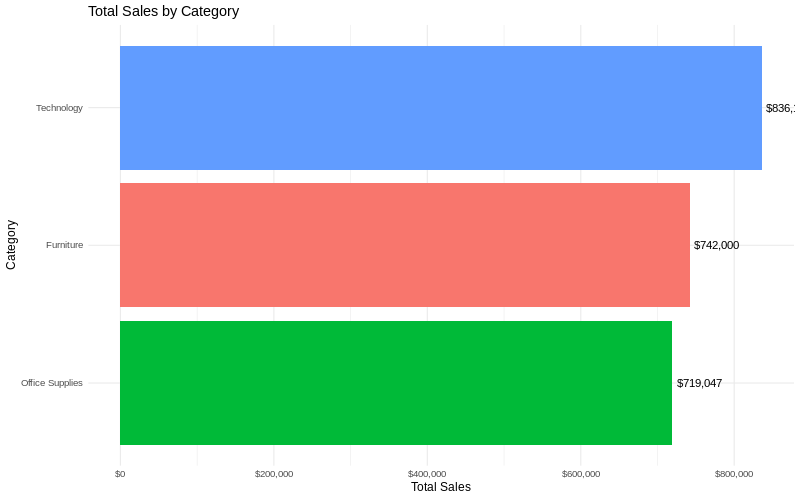

In [24]:
%%R -w 800 -h 500
ggplot(category_sales, aes(x = reorder(Category, Total_Sales), y = Total_Sales, fill = Category)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = dollar(Total_Sales)), hjust = -0.1, size = 4) +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Total Sales by Category", x = "Category", y = "Total Sales") +
  theme(legend.position = "none")

 Plot 2 - Sales by Sub-Category

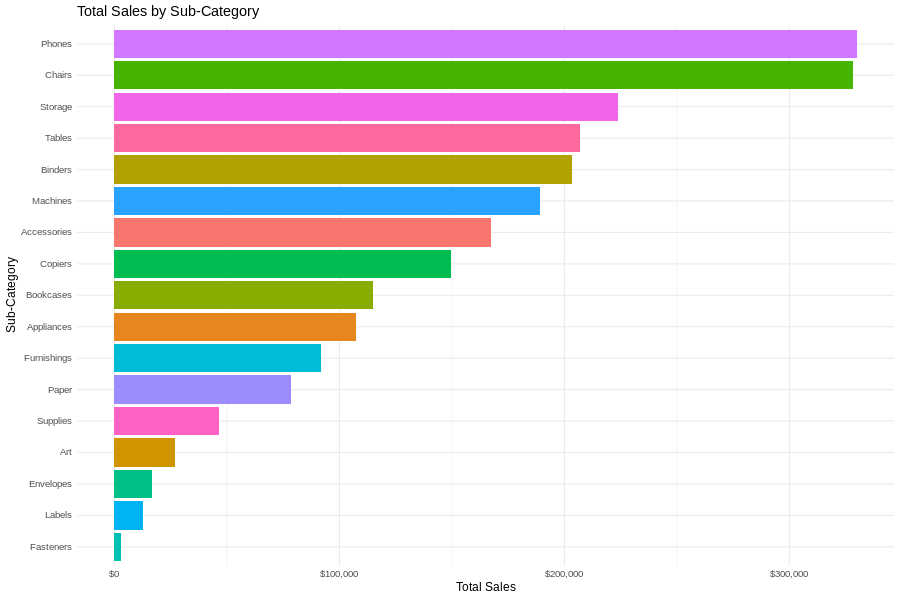

In [25]:
%%R -w 900 -h 600
ggplot(subcategory_sales, aes(x = reorder(Sub.Category, Total_Sales), y = Total_Sales, fill = Sub.Category)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Total Sales by Sub-Category", x = "Sub-Category", y = "Total Sales") +
  theme(legend.position = "none")

 Plot 3 - Profit by Category

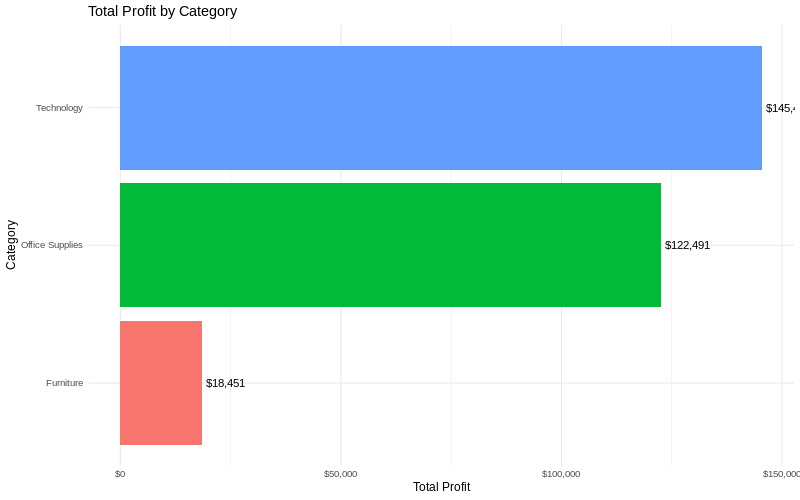

In [26]:
%%R -w 800 -h 500
ggplot(category_sales, aes(x = reorder(Category, Total_Profit), y = Total_Profit, fill = Category)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = dollar(Total_Profit)),
            hjust = ifelse(category_sales$Total_Profit > 0, -0.1, 1.1), size = 4) +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Total Profit by Category", x = "Category", y = "Total Profit") +
  theme(legend.position = "none")

Plot 4 - Sales by Segment (Pie)

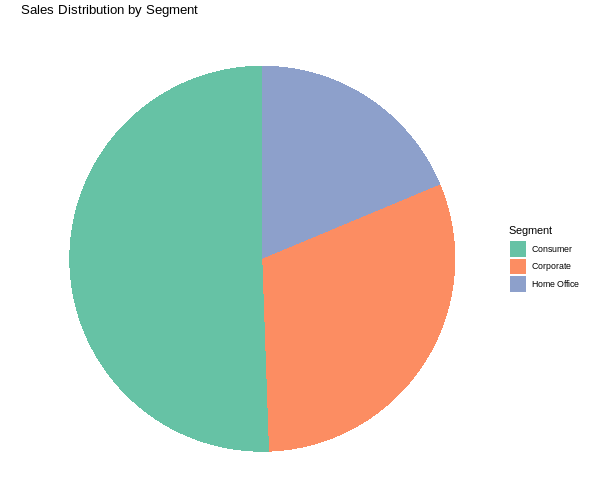

In [27]:
%%R -w 600 -h 500
ggplot(segment_sales, aes(x = "", y = Total_Sales, fill = Segment)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Sales Distribution by Segment") +
  theme_void() +
  theme(legend.position = "right")

Plot 5 - Sales by Region

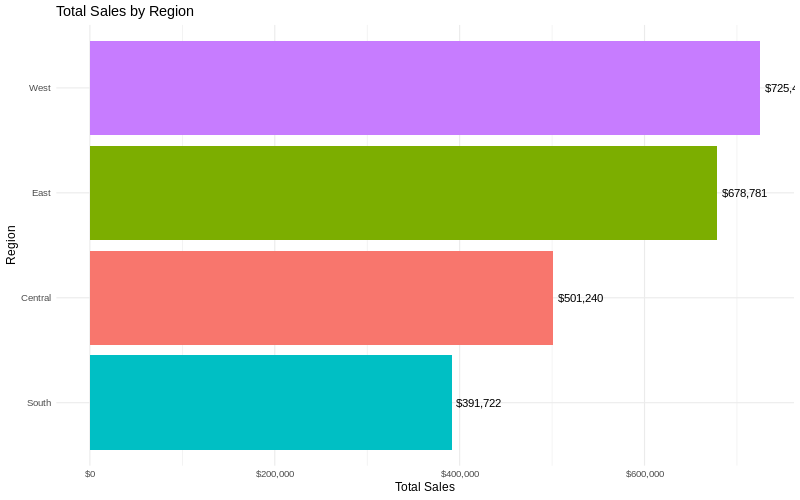

In [28]:
%%R -w 800 -h 500
ggplot(region_sales, aes(x = reorder(Region, Total_Sales), y = Total_Sales, fill = Region)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = dollar(Total_Sales)), hjust = -0.1, size = 4) +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Total Sales by Region", x = "Region", y = "Total Sales") +
  theme(legend.position = "none")

Plot 6 - Yearly Sales Trend

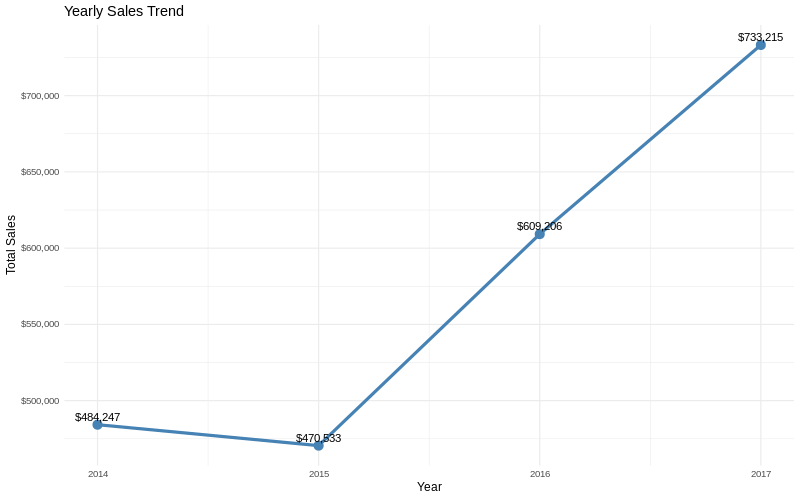

In [29]:
%%R -w 800 -h 500
ggplot(yearly_sales, aes(x = Order.Year, y = Total_Sales)) +
  geom_line(color = "steelblue", size = 1.5) +
  geom_point(color = "steelblue", size = 4) +
  geom_text(aes(label = dollar(Total_Sales)), vjust = -0.5, size = 4) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Yearly Sales Trend", x = "Year", y = "Total Sales")

Plot 7 - Monthly Sales Pattern

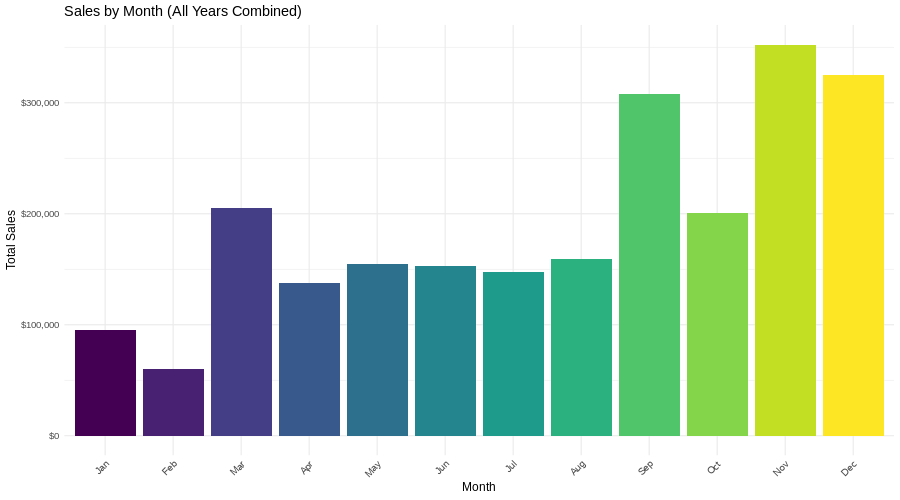

In [30]:
%%R -w 900 -h 500
ggplot(monthly_sales, aes(x = Order.Month, y = Total_Sales, fill = Order.Month)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Sales by Month (All Years Combined)", x = "Month", y = "Total Sales") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 45, hjust = 1))

 Plot 8 - Sales vs Profit Scatter

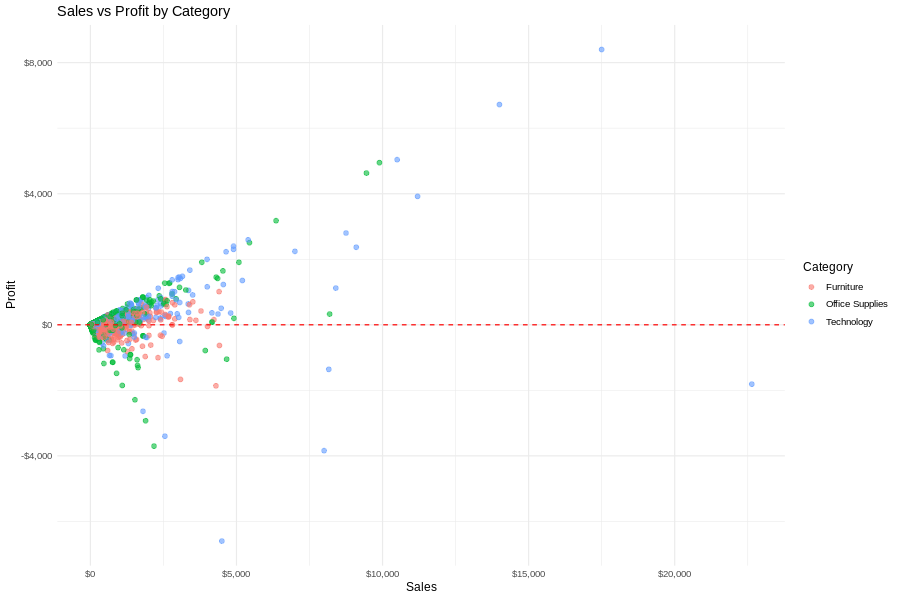

In [31]:
%%R -w 900 -h 600
ggplot(df, aes(x = Sales, y = Profit, color = Category)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  scale_x_continuous(labels = dollar_format()) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Sales vs Profit by Category", x = "Sales", y = "Profit")

Plot 9 - Discount vs Profit

`geom_smooth()` using formula = 'y ~ x'


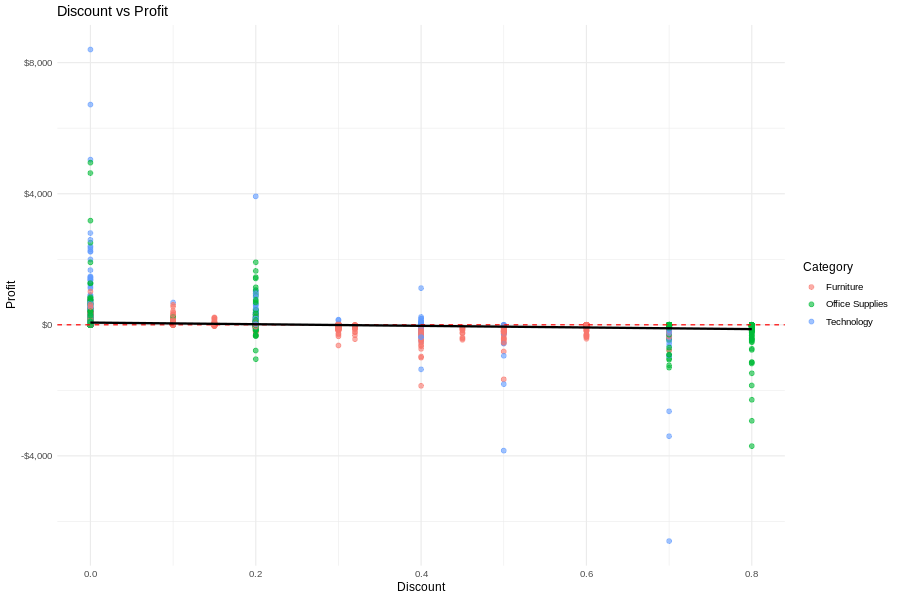

In [32]:
%%R -w 900 -h 600
ggplot(df, aes(x = Discount, y = Profit, color = Category)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_smooth(method = "lm", se = FALSE, color = "black") +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Discount vs Profit", x = "Discount", y = "Profit")

Plot 10 - Ship Mode Distribution

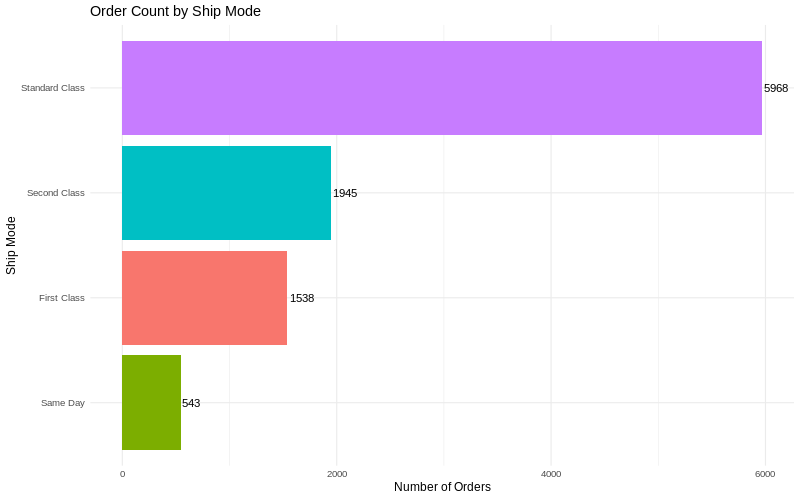

In [33]:
%%R -w 800 -h 500
ggplot(ship_mode_analysis, aes(x = reorder(Ship.Mode, Order_Count), y = Order_Count, fill = Ship.Mode)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = Order_Count), hjust = -0.1, size = 4) +
  coord_flip() +
  labs(title = "Order Count by Ship Mode", x = "Ship Mode", y = "Number of Orders") +
  theme(legend.position = "none")

 Plot 11 - Top 10 Customers

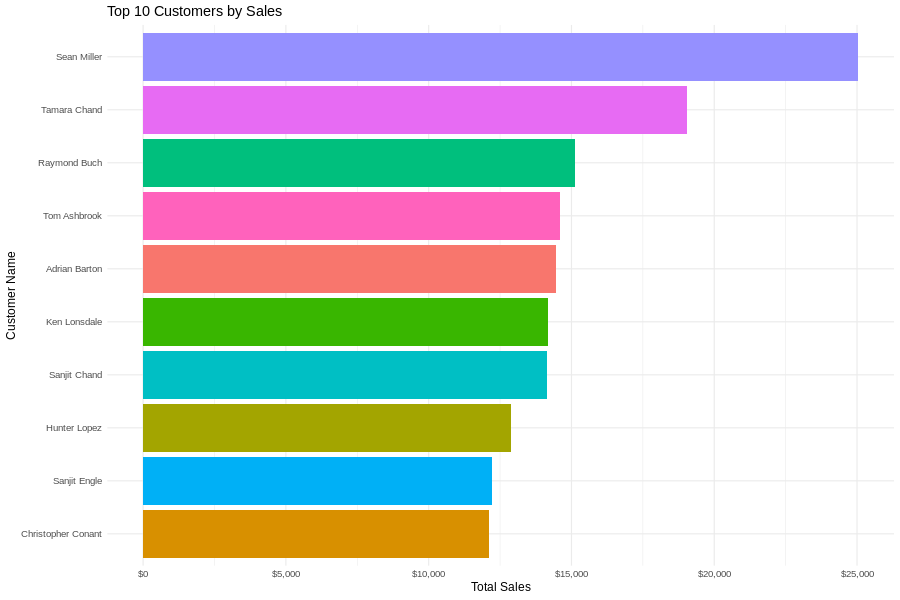

In [34]:
%%R -w 900 -h 600
ggplot(top_customers, aes(x = reorder(Customer.Name, Total_Sales), y = Total_Sales, fill = Customer.Name)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Top 10 Customers by Sales", x = "Customer Name", y = "Total Sales") +
  theme(legend.position = "none")

Plot 12 - Profit Margin by Sub-Category

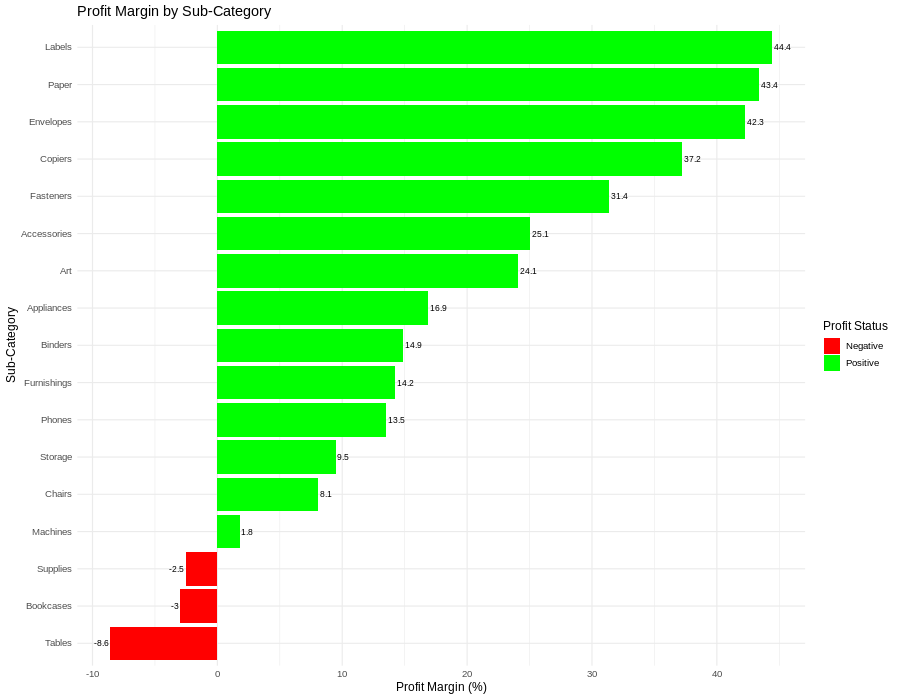

In [36]:
%%R -w 900 -h 700
# Calculate profit margin by sub-category
profit_margin_subcategory <- df %>%
  group_by(Sub.Category) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Profit_Margin = (Total_Profit / Total_Sales) * 100
  ) %>%
  arrange(desc(Profit_Margin))

ggplot(profit_margin_subcategory,
       aes(x = reorder(Sub.Category, Profit_Margin), y = Profit_Margin, fill = Profit_Margin > 0)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("red", "green"), labels = c("Negative", "Positive")) +
  geom_text(aes(label = round(Profit_Margin, 1)),
            hjust = ifelse(profit_margin_subcategory$Profit_Margin > 0, -0.1, 1.1), size = 3) +
  coord_flip() +
  labs(title = "Profit Margin by Sub-Category", x = "Sub-Category", y = "Profit Margin (%)", fill = "Profit Status")

 Plot 13 - Sales Distribution Histogram

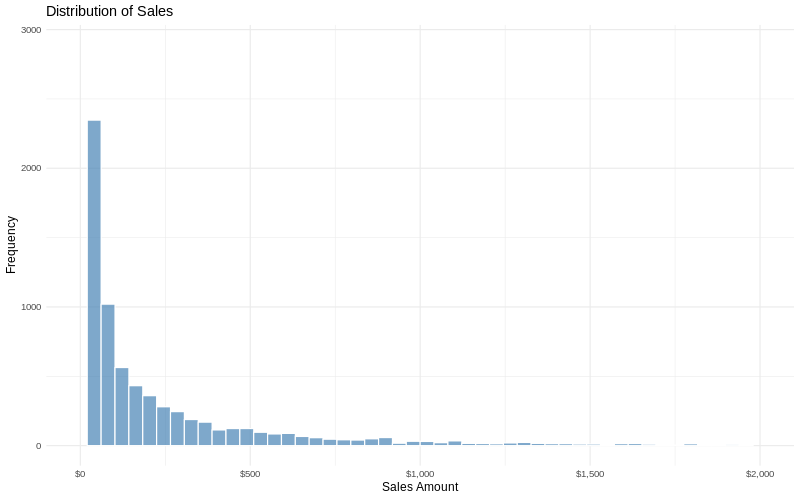

In [37]:
%%R -w 800 -h 500
ggplot(df, aes(x = Sales)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white", alpha = 0.7) +
  scale_x_continuous(labels = dollar_format(), limits = c(0, 2000)) +
  labs(title = "Distribution of Sales", x = "Sales Amount", y = "Frequency")

Plot 14 - Profit Distribution Histogram

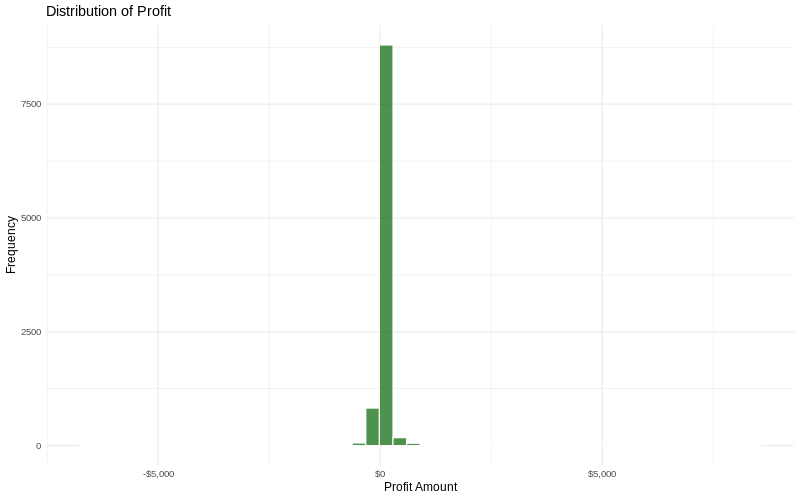

In [38]:
%%R -w 800 -h 500
ggplot(df, aes(x = Profit)) +
  geom_histogram(bins = 50, fill = "darkgreen", color = "white", alpha = 0.7) +
  scale_x_continuous(labels = dollar_format()) +
  labs(title = "Distribution of Profit", x = "Profit Amount", y = "Frequency")

Plot 15 - Quantity by Category (Box Plot)

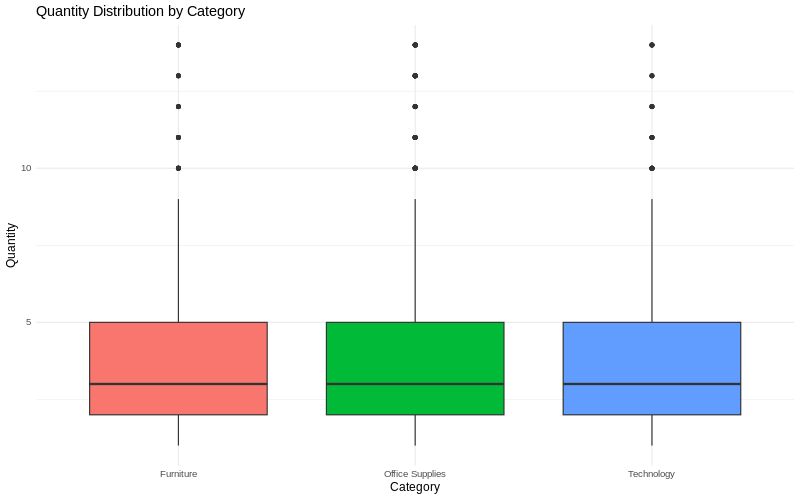

In [39]:
%%R -w 800 -h 500
ggplot(df, aes(x = Category, y = Quantity, fill = Category)) +
  geom_boxplot() +
  labs(title = "Quantity Distribution by Category", x = "Category", y = "Quantity") +
  theme(legend.position = "none")

Plot 16 - Correlation Heatmap

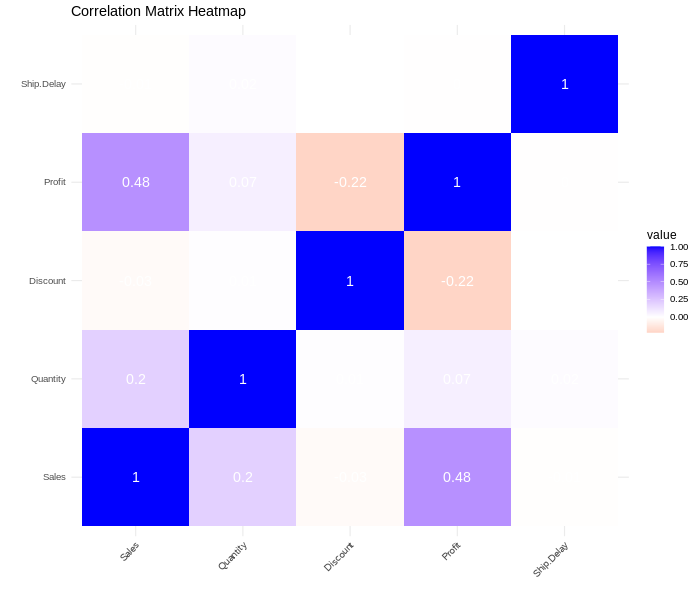

In [40]:
%%R -w 700 -h 600
cor_melted <- melt(correlation_matrix)
ggplot(cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2)), color = "white", size = 5) +
  scale_fill_gradient2(low = "red", high = "blue", mid = "white", midpoint = 0) +
  labs(title = "Correlation Matrix Heatmap", x = "", y = "") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Plot 17 - Top 10 States by Sales

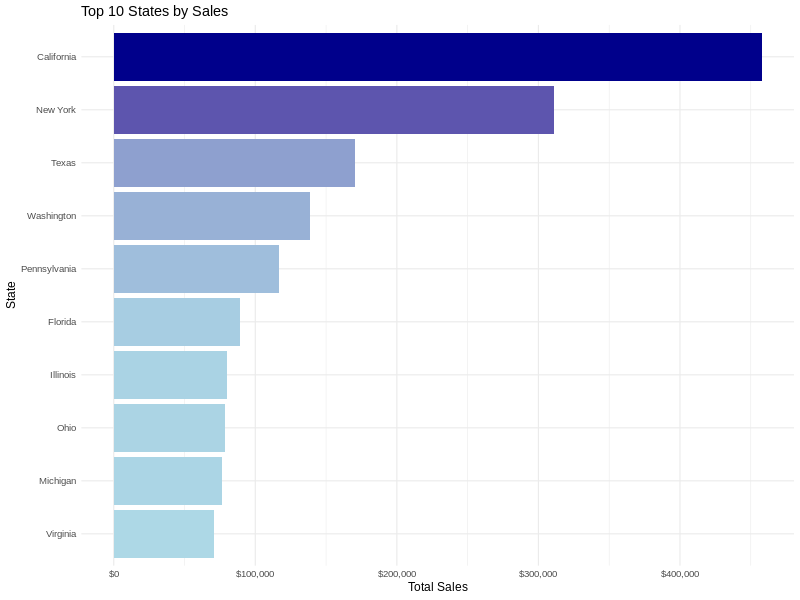

In [41]:
%%R -w 800 -h 600
ggplot(top_states, aes(x = reorder(State, Total_Sales), y = Total_Sales, fill = Total_Sales)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Top 10 States by Sales", x = "State", y = "Total Sales") +
  theme(legend.position = "none")

Plot 18 - Sales & Profit by Year (Dual Axis)

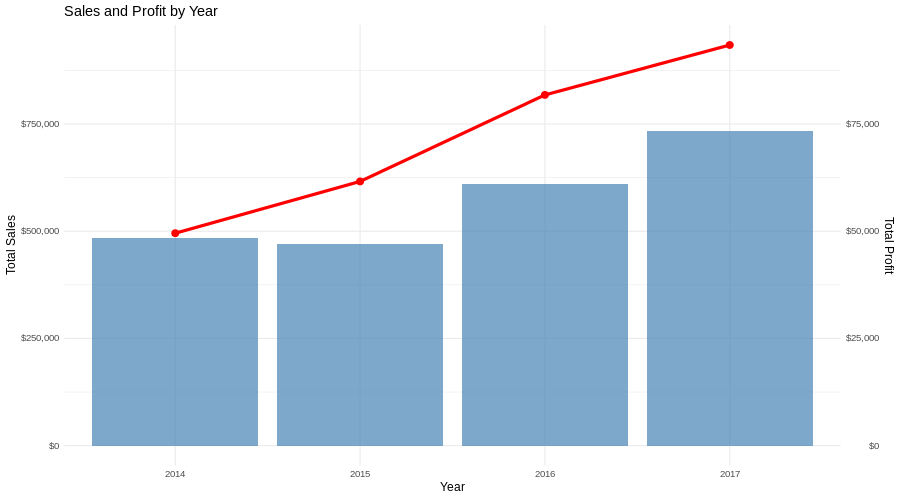

In [42]:
%%R -w 900 -h 500
ggplot(yearly_sales) +
  geom_bar(aes(x = factor(Order.Year), y = Total_Sales), stat = "identity", fill = "steelblue", alpha = 0.7) +
  geom_line(aes(x = factor(Order.Year), y = Total_Profit * 10, group = 1), color = "red", size = 1.5) +
  geom_point(aes(x = factor(Order.Year), y = Total_Profit * 10), color = "red", size = 3) +
  scale_y_continuous(
    name = "Total Sales",
    labels = dollar_format(),
    sec.axis = sec_axis(~./10, name = "Total Profit", labels = dollar_format())
  ) +
  labs(title = "Sales and Profit by Year", x = "Year")

Plot 19 - Shipping Delay Distribution

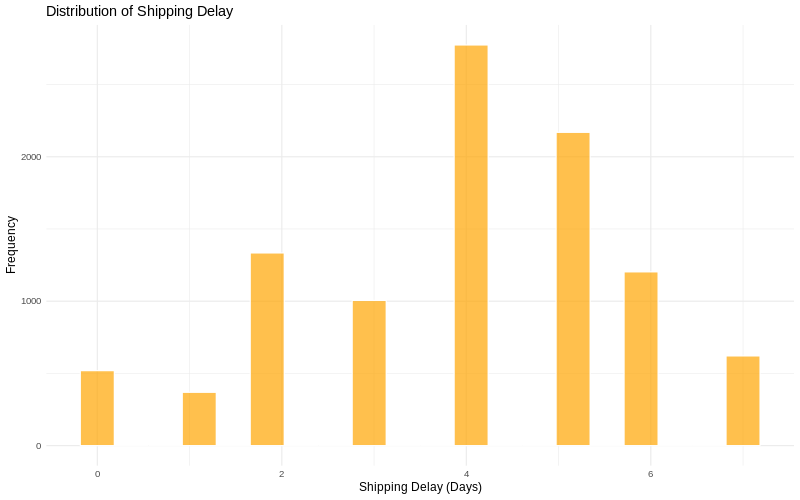

In [43]:
%%R -w 800 -h 500
ggplot(df, aes(x = Ship.Delay)) +
  geom_histogram(bins = 20, fill = "orange", color = "white", alpha = 0.7) +
  labs(title = "Distribution of Shipping Delay", x = "Shipping Delay (Days)", y = "Frequency")

: Plot 20 - Sales by Discount Level

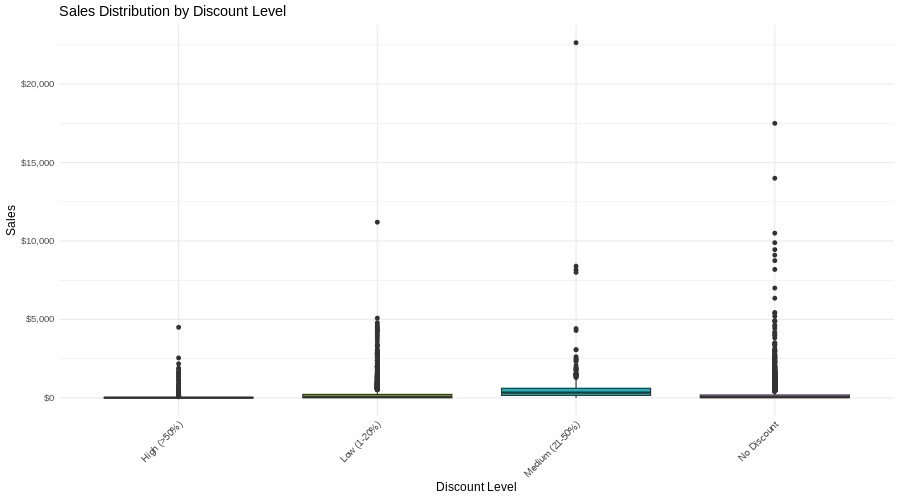

In [44]:
%%R -w 900 -h 500
discount_viz <- df %>%
  mutate(Discount_Level = case_when(
    Discount == 0 ~ "No Discount",
    Discount <= 0.2 ~ "Low (1-20%)",
    Discount <= 0.5 ~ "Medium (21-50%)",
    TRUE ~ "High (>50%)"
  ))

ggplot(discount_viz, aes(x = Discount_Level, y = Sales, fill = Discount_Level)) +
  geom_boxplot() +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Sales Distribution by Discount Level", x = "Discount Level", y = "Sales") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 45, hjust = 1))

Plot 21 - Monthly Trend by Year

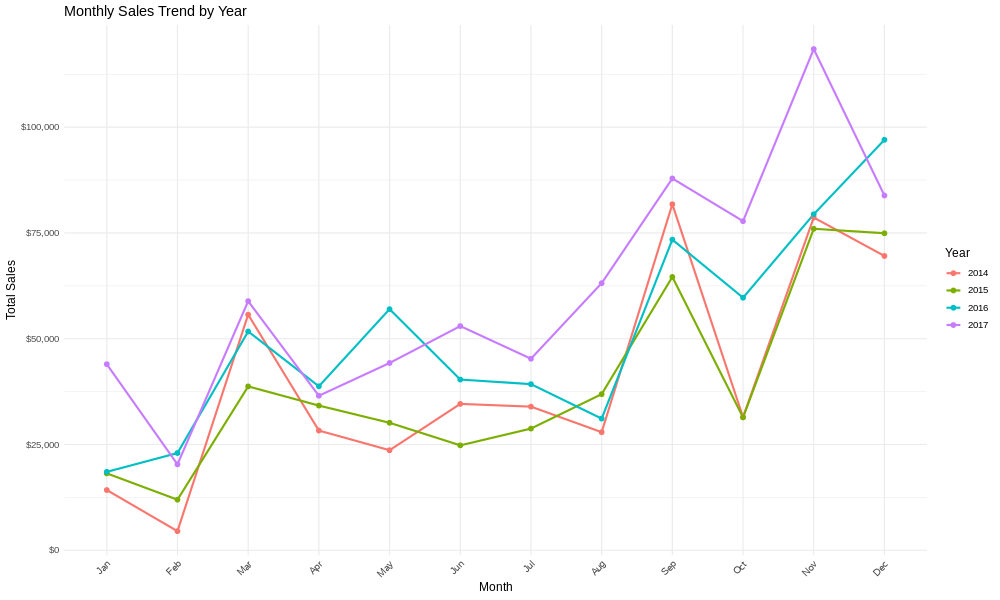

In [45]:
%%R -w 1000 -h 600
ggplot(monthly_trend, aes(x = Order.Month, y = Total_Sales, color = factor(Order.Year), group = Order.Year)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Monthly Sales Trend by Year", x = "Month", y = "Total Sales", color = "Year") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Plot 22 - Sales vs Quantity

`geom_smooth()` using formula = 'y ~ x'


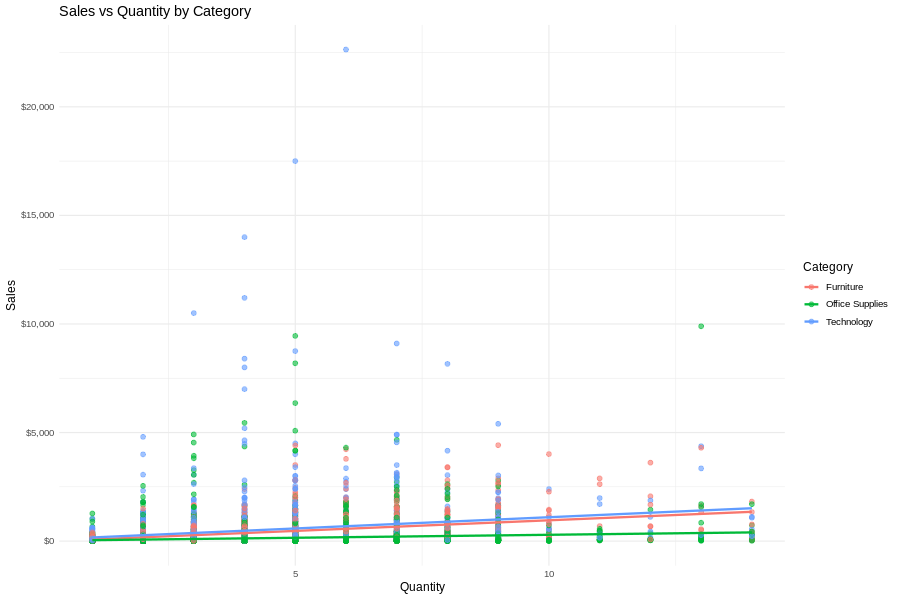

In [46]:
%%R -w 900 -h 600
ggplot(df, aes(x = Quantity, y = Sales, color = Category)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Sales vs Quantity by Category", x = "Quantity", y = "Sales")

Plot 23 - Average Order Value by Segment

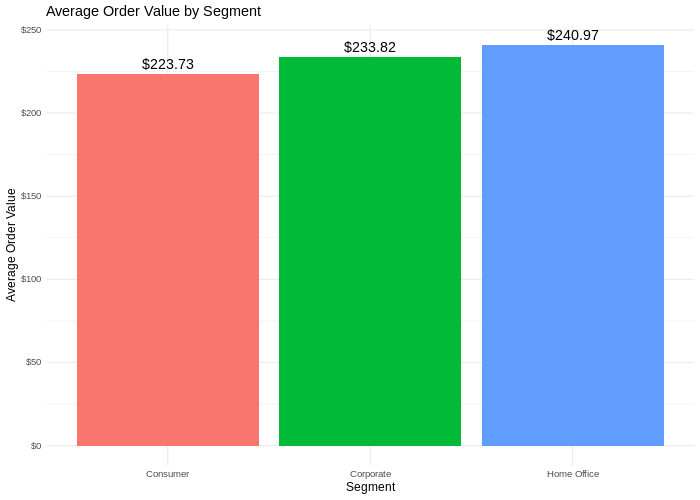

In [48]:
%%R -w 700 -h 500
aov_segment <- df %>%
  group_by(Segment) %>%
  summarise(Avg_Order_Value = mean(Sales))

ggplot(aov_segment, aes(x = Segment, y = Avg_Order_Value, fill = Segment)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = dollar(Avg_Order_Value)), vjust = -0.5, size = 5) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Average Order Value by Segment", x = "Segment", y = "Average Order Value") +
  theme(legend.position = "none")

Plot 24 - Profit by Ship Mode

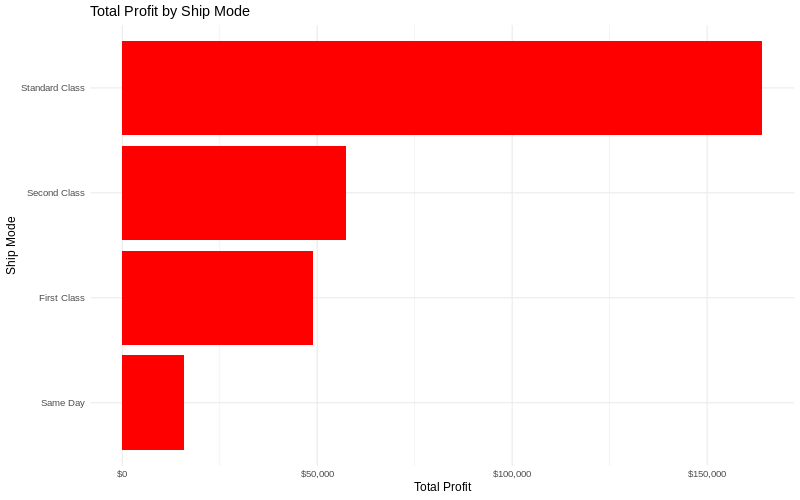

In [49]:
%%R -w 800 -h 500
profit_ship <- df %>%
  group_by(Ship.Mode) %>%
  summarise(Total_Profit = sum(Profit))

ggplot(profit_ship, aes(x = reorder(Ship.Mode, Total_Profit), y = Total_Profit, fill = Total_Profit > 0)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("red", "green")) +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Total Profit by Ship Mode", x = "Ship Mode", y = "Total Profit") +
  theme(legend.position = "none")

Plot 25 - Sales Density by Category

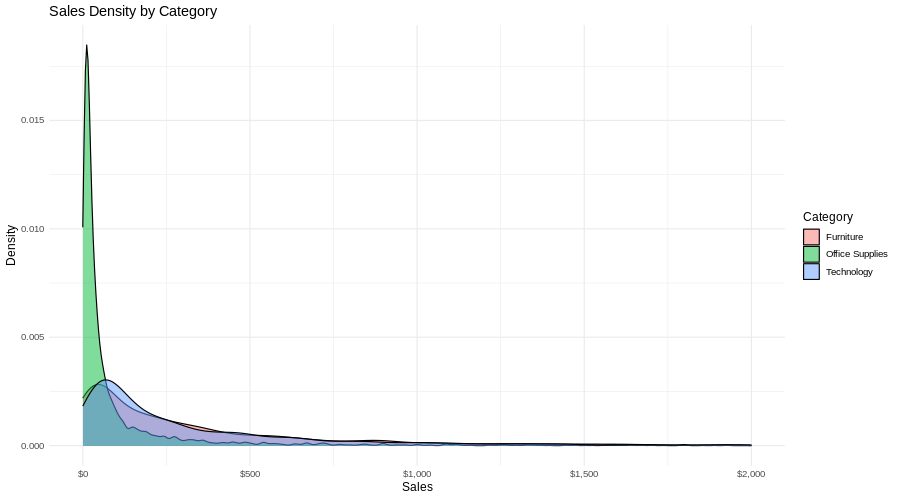

In [50]:
%%R -w 900 -h 500
ggplot(df, aes(x = Sales, fill = Category)) +
  geom_density(alpha = 0.5) +
  scale_x_continuous(labels = dollar_format(), limits = c(0, 2000)) +
  labs(title = "Sales Density by Category", x = "Sales", y = "Density")

Plot 26 - Top 10 Loss-Making Products

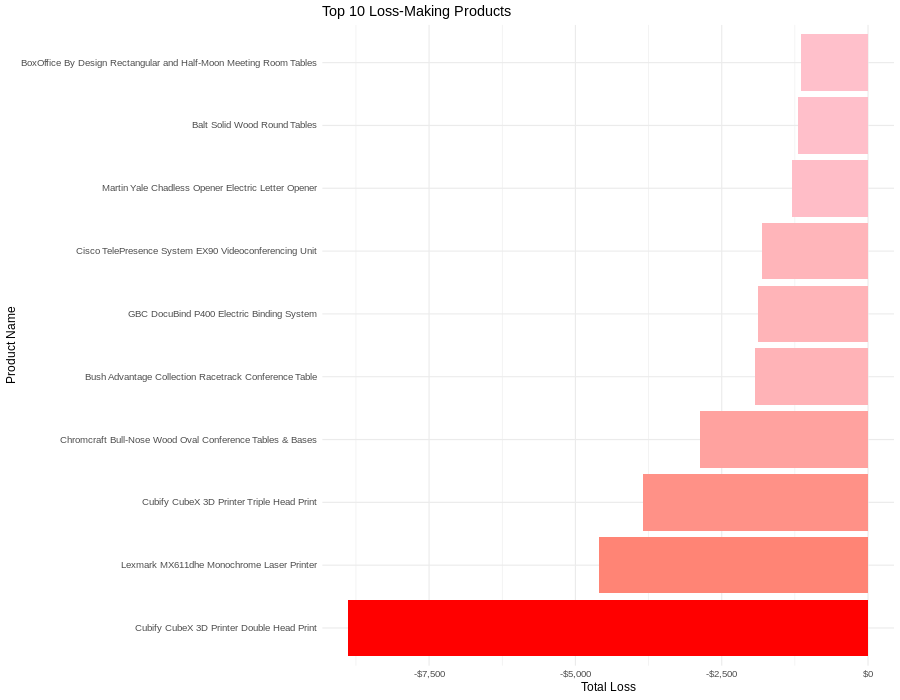

In [51]:
%%R -w 900 -h 700
loss_top10 <- loss_products %>% head(10)

ggplot(loss_top10, aes(x = reorder(Product.Name, Total_Profit), y = Total_Profit, fill = Total_Profit)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "red", high = "pink") +
  scale_y_continuous(labels = dollar_format()) +
  coord_flip() +
  labs(title = "Top 10 Loss-Making Products", x = "Product Name", y = "Total Loss") +
  theme(legend.position = "none")

Plot 27 - Sales by Region & Category

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Region and Category.
ℹ Output is grouped by Region.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Region, Category))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


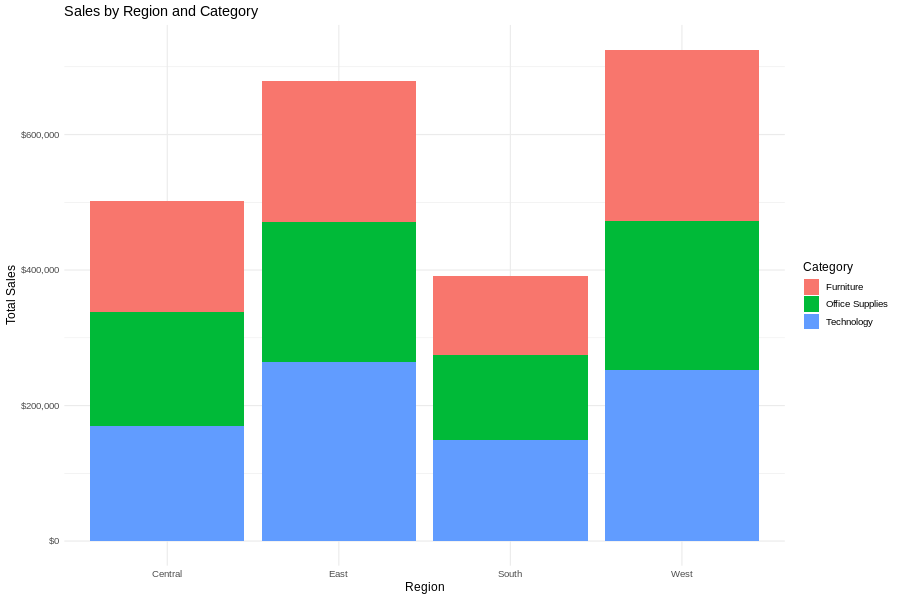

In [52]:
%%R -w 900 -h 600
region_category <- df %>%
  group_by(Region, Category) %>%
  summarise(Total_Sales = sum(Sales)) %>%
  ungroup()

ggplot(region_category, aes(x = Region, y = Total_Sales, fill = Category)) +
  geom_bar(stat = "identity", position = "stack") +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Sales by Region and Category", x = "Region", y = "Total Sales", fill = "Category")

Plot 28 - Profit Margin Heatmap (Segment × Category)


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Segment and Category.
ℹ Output is grouped by Segment.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Segment, Category))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


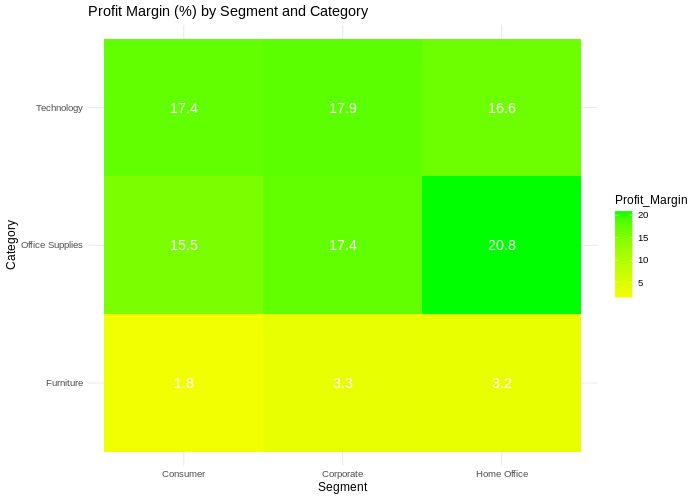

In [53]:
%%R -w 700 -h 500
segment_category_profit <- df %>%
  group_by(Segment, Category) %>%
  summarise(
    Total_Sales = sum(Sales),
    Total_Profit = sum(Profit),
    Profit_Margin = (Total_Profit / Total_Sales) * 100
  ) %>%
  ungroup()

ggplot(segment_category_profit, aes(x = Segment, y = Category, fill = Profit_Margin)) +
  geom_tile() +
  geom_text(aes(label = round(Profit_Margin, 1)), color = "white", size = 5) +
  scale_fill_gradient2(low = "red", high = "green", mid = "yellow", midpoint = 0) +
  labs(title = "Profit Margin (%) by Segment and Category", x = "Segment", y = "Category")

Plot 29 - Order Count by Month & Year

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Order.Year and Order.Month.
ℹ Output is grouped by Order.Year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Order.Year, Order.Month))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


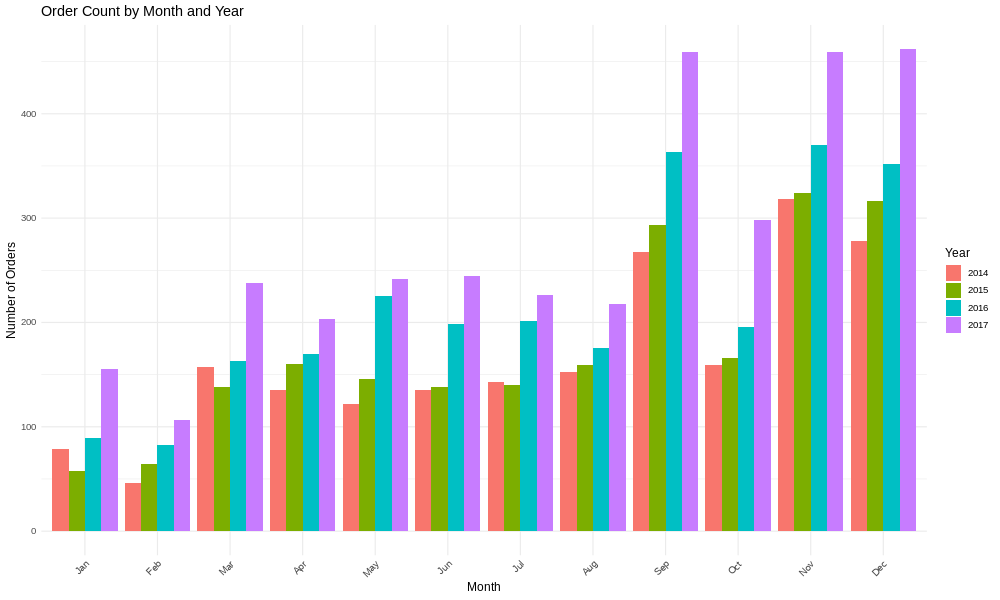

In [54]:
%%R -w 1000 -h 600
orders_monthly <- df %>%
  group_by(Order.Year, Order.Month) %>%
  summarise(Order_Count = n()) %>%
  ungroup()

ggplot(orders_monthly, aes(x = Order.Month, y = Order_Count, fill = factor(Order.Year))) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Order Count by Month and Year", x = "Month", y = "Number of Orders", fill = "Year") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Plot 30 - Cumulative Sales Over Time

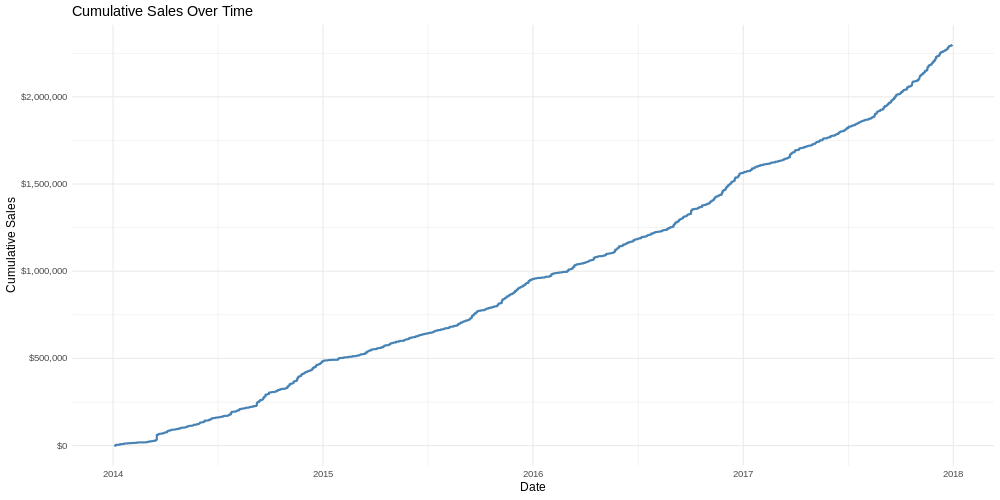

In [55]:
%%R -w 1000 -h 500
cumulative_sales <- df %>%
  arrange(Order.Date) %>%
  mutate(Cumulative_Sales = cumsum(Sales))

ggplot(cumulative_sales, aes(x = Order.Date, y = Cumulative_Sales)) +
  geom_line(color = "steelblue", size = 1) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Cumulative Sales Over Time", x = "Date", y = "Cumulative Sales")

Save Results to CSV

In [56]:
%%R
# Save summary tables
write.csv(category_sales, "/content/category_sales_summary.csv", row.names = FALSE)
write.csv(subcategory_sales, "/content/subcategory_sales_summary.csv", row.names = FALSE)
write.csv(segment_sales, "/content/segment_sales_summary.csv", row.names = FALSE)
write.csv(region_sales, "/content/region_sales_summary.csv", row.names = FALSE)
write.csv(yearly_sales, "/content/yearly_sales_summary.csv", row.names = FALSE)
write.csv(monthly_sales, "/content/monthly_sales_summary.csv", row.names = FALSE)
write.csv(top_customers, "/content/top_customers.csv", row.names = FALSE)
write.csv(top_products, "/content/top_products.csv", row.names = FALSE)
write.csv(df, "/content/cleaned_superstore_data.csv", row.names = FALSE)

cat("\n========================================\n")
cat("ANALYSIS COMPLETE!\n")
cat("========================================\n")
cat("Total Records Analyzed:", nrow(df), "\n")
cat("Total Sales: $", format(total_sales, big.mark = ","), "\n")
cat("Total Profit: $", format(total_profit, big.mark = ","), "\n")
cat("Profit Margin:", round(profit_margin, 2), "%\n")
cat("Date Range:", format(min(df$Order.Date), "%Y-%m-%d"), "to", format(max(df$Order.Date), "%Y-%m-%d"), "\n")
cat("\nAll CSV files saved to /content/\n")


ANALYSIS COMPLETE!
Total Records Analyzed: 9994 
Total Sales: $ 2,297,201 
Total Profit: $ 286,397 
Profit Margin: 12.47 %
Date Range: 2014-01-03 to 2017-12-30 

All CSV files saved to /content/


Download Files

In [57]:
from google.colab import files

# Download all generated CSVs
files.download('/content/category_sales_summary.csv')
files.download('/content/subcategory_sales_summary.csv')
files.download('/content/segment_sales_summary.csv')
files.download('/content/region_sales_summary.csv')
files.download('/content/yearly_sales_summary.csv')
files.download('/content/monthly_sales_summary.csv')
files.download('/content/top_customers.csv')
files.download('/content/top_products.csv')
files.download('/content/cleaned_superstore_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>